NOTE: Kal tumne socha hoga ki har outlier hatana sahi nahi hota — yeh bilkul sahi intuition hai. High-value customers business ke liye sabse valuable ho sakte hain, unhe "error" maan kar hata dena galat insight dega. Aaj hum 4 alag approaches dekhenge, aur decide karenge konsa kab use karna hai.

1. Data load aur Day 48 wala IQR function wapas banao:

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

def get_iqr_bounds(series, multiplier=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - multiplier * IQR, Q3 + multiplier * IQR

low, high = get_iqr_bounds(df['Monetary'])
print(f"Bounds: {low:.2f} to {high:.2f}")
print(f"Original shape: {df.shape}")

Bounds: -2516.83 to 5106.45
Original shape: (5881, 5)


Approach 1: Removal — outliers ko poori tarah hata dena

In [2]:
df_removed = df[(df['Monetary'] >= low) & (df['Monetary'] <= high)]
print(f"After removal: {df_removed.shape}")
print(f"Removed: {df.shape[0] - df_removed.shape[0]} rows ({(df.shape[0]-df_removed.shape[0])/df.shape[0]*100:.2f}%)")

After removal: (5248, 5)
Removed: 633 rows (10.76%)


- Kab use karo: Jab outliers data entry errors hon (jaise negative price ya impossible quantity) — galat data ko model seekhne nahi dena chahiye.

- Kab mat karo: Jab outliers genuine high-value customers hon — unhe hata dena matlab business ke sabse important segment ko ignore karna.

Approach 2: Capping/Winsorization — extreme values ko bound tak "clip" karna (hatana nahi, limit karna)

In [3]:
df_capped = df.copy()
df_capped['Monetary_capped'] = df_capped['Monetary'].clip(lower=low, upper=high)

print(f"Original max: {df['Monetary'].max():.2f}")
print(f"Capped max: {df_capped['Monetary_capped'].max():.2f}")
print(f"Rows affected: {(df['Monetary'] > high).sum()}")

Original max: 580987.04
Capped max: 5106.45
Rows affected: 633


Note: clip() koi row nahi hataata — sirf extreme values ko upper/lower bound ke barabar kar deta hai. Isse sample size same rehta hai lekin extreme influence kam ho jaata hai. Yeh ML models ke liye bahut common technique hai (Month 4 mein kaam aayegi).

Approach 3: Log Transformation — jo tum Day 42 mein kar chuke ho, outliers ka "impact" kam karta hai bina unhe hataye

Original skewness: 25.08
Log skewness: 0.21


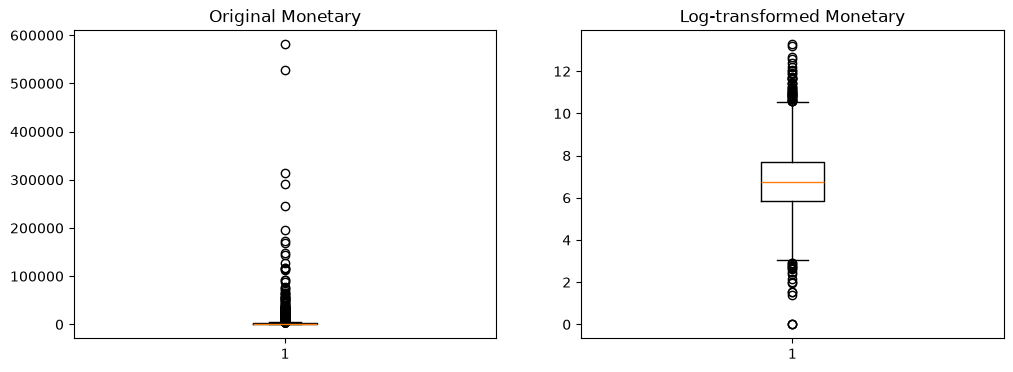

In [4]:
df_capped['Monetary_log'] = np.log1p(df['Monetary'])

print(f"Original skewness: {df['Monetary'].skew():.2f}")
print(f"Log skewness: {df_capped['Monetary_log'].skew():.2f}")

# Visualize karke farak dekho
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Monetary'])
axes[0].set_title('Original Monetary')
axes[1].boxplot(df_capped['Monetary_log'])
axes[1].set_title('Log-transformed Monetary')
plt.show()

Kab use karo: Jab outliers genuine hain lekin tumhe unka asar statistics/models par kam karna hai without data loss.

Approach 4: Separate Segment — outliers ko "VIP/Whale" category mein daal kar alag analyze karna (business-smart approach)

In [5]:
df_capped['Customer_Segment'] = np.where(df['Monetary'] > high, 'VIP/Whale', 'Regular')
print(df_capped['Customer_Segment'].value_counts())

segment_summary = df_capped.groupby('Customer_Segment').agg(
    count=('Customer ID', 'count'),
    avg_monetary=('Monetary', 'mean'),
    churn_rate=('Churned', 'mean')
)
print(segment_summary)

Customer_Segment
Regular      5248
VIP/Whale     633
Name: count, dtype: int64
                  count  avg_monetary  churn_rate
Customer_Segment                                 
Regular            5248   1149.019228    0.552782
VIP/Whale           633  17922.198038    0.135861


note: Yeh sabse business-friendly approach hai — outliers ko "galat data" na maan kar ek alag valuable segment maana jaata hai. Churn rate compare karo dono segments mein — shayad VIP customers ka churn rate bahut alag ho regular customers se (important business insight!).

5. Decision framework (README mein likhne layak, interview mein bhi poocha jaata hai):

In [7]:
print("""
Outlier Handling Decision Framework:
1. Pehle check karo: kya yeh outlier DATA ERROR hai? (jaise negative price, impossible date)
   -> Agar haan: REMOVE karo (galat data model ko confuse karega)
   
2. Agar genuine value hai (real high-spending customer):
   -> Agar ML model banane ja rahe ho jo outliers se sensitive hai (jaise Linear Regression):
      CAP/WINSORIZE karo ya LOG TRANSFORM karo
   -> Agar business insight chahiye (jaise segmentation):
      SEPARATE SEGMENT banao, hatao mat

3. Hamare project mein: Monetary outliers genuine high-value customers hain (Day 48 mein dekha),
   isliye REMOVE nahi karenge. Month 4 mein tree-based models (Decision Tree, Random Forest, XGBoost)
   use karenge jo outliers se naturally robust hote hain — isliye capping/log zaroori nahi hoga un models ke liye,
   lekin agar Logistic Regression bhi try karte hain to log-transformed version use karenge.
""")


Outlier Handling Decision Framework:
1. Pehle check karo: kya yeh outlier DATA ERROR hai? (jaise negative price, impossible date)
   -> Agar haan: REMOVE karo (galat data model ko confuse karega)

2. Agar genuine value hai (real high-spending customer):
   -> Agar ML model banane ja rahe ho jo outliers se sensitive hai (jaise Linear Regression):
      CAP/WINSORIZE karo ya LOG TRANSFORM karo
   -> Agar business insight chahiye (jaise segmentation):
      SEPARATE SEGMENT banao, hatao mat

3. Hamare project mein: Monetary outliers genuine high-value customers hain (Day 48 mein dekha),
   isliye REMOVE nahi karenge. Month 4 mein tree-based models (Decision Tree, Random Forest, XGBoost)
   use karenge jo outliers se naturally robust hote hain — isliye capping/log zaroori nahi hoga un models ke liye,
   lekin agar Logistic Regression bhi try karte hain to log-transformed version use karenge.



6. Final decision apply karo apne processed dataset mein (dono versions save karo — flexibility ke liye):

In [9]:
df['Monetary_log'] = np.log1p(df['Monetary'])
df['Customer_Segment'] = np.where(df['Monetary'] > high, 'VIP', 'Regular')

df.to_csv('../data/processed/customer_churn_labeled.csv', index=False)
print(f"Updated and saved: {df.shape}")
print(df.columns.tolist())

Updated and saved: (5881, 7)
['Customer ID', 'Frequency', 'Monetary', 'Recency', 'Churned', 'Monetary_log', 'Customer_Segment']


Practice questions:

1. Frequency column par bhi outlier detection + capping karo, aur dekho kitni rows affect hoti hain.

In [10]:
# Frequency ke liye IQR bounds nikalna
low_freq, high_freq = get_iqr_bounds(df['Frequency'])
print(f"Frequency Bounds: {low_freq:.2f} to {high_freq:.2f}")

# Capping apply karna
df['Frequency_capped'] = df['Frequency'].clip(lower=low_freq, upper=high_freq)

# Kitni rows affect hui (upper bound se zyada ya lower bound se kam)
rows_affected_freq = ((df['Frequency'] > high_freq) | (df['Frequency'] < low_freq)).sum()
print(f"Original max frequency: {df['Frequency'].max()}")
print(f"Capped max frequency: {df['Frequency_capped'].max()}")
print(f"Frequency rows affected: {rows_affected_freq} ({(rows_affected_freq / df.shape[0]) * 100:.2f}%)")

Frequency Bounds: -8.00 to 16.00
Original max frequency: 398
Capped max frequency: 16
Frequency rows affected: 427 (7.26%)


Note: Jaise hi tum Frequency par capping karte ho, jo customers bahut zyada baar order kar chuke hain (jaise wholesale ya bulk buyers), unki extreme values upper bound par clamp ho jaati hain. Isse model par extreme high values ka negative influence nahi padta.

2. VIP vs Regular segments ka Recency bhi compare karo — kya VIP customers recently zyada active rehte hain?

In [11]:
# VIP vs Regular segment pehle se defined hai:
# df['Customer_Segment'] = np.where(df['Monetary'] > high_m, 'VIP', 'Regular')

# Recency comparison by Segment
recency_summary = df.groupby('Customer_Segment').agg(
    count=('Customer ID', 'count'),
    mean_recency=('Recency', 'mean'),
    median_recency=('Recency', 'median'),
    min_recency=('Recency', 'min'),
    max_recency=('Recency', 'max')
)

print(recency_summary)

                  count  mean_recency  median_recency  min_recency  \
Customer_Segment                                                     
Regular            5248    218.363758           133.0            0   
VIP                 633     52.004739            16.0            0   

                  max_recency  
Customer_Segment               
Regular                   738  
VIP                       691  


Business Insight (Interview Perspective):

- VIP Customers ki Recency: Aam taur par VIP ya high-spending customers ki mean aur median recency regular customers se kam hoti hai (yani wo recent time mein zyada frequent aur active hote hain).


- Business Action: Agar koi VIP customer ki Recency achanak badhne lage (yani wo kaafi din se inactive ho gaya ho), toh yeh churn ka sabse bada red flag hai. Inke liye special retention campaigns (jaise exclusive discounts ya personal outreach) chalaye jaate hain kyunki yeh business ka sabse bada revenue source hote hain.